# 温度与时钟频率关系分析

分析设备100和101的温度与其时钟频率漂移之间的关系

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [12, 8]    
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import pandas as pd
from scipy import optimize

def load_sync_data(filepath, window_seconds=2):
    """加载同步数据并计算频率漂移"""
    # 先读取文件并过滤掉注释行
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('//')]
    
    # 解析数据
    data = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 4:
            try:
                t1, t2, t3, t4 = map(float, parts[:4])
                data.append([t1, t2, t3, t4])
            except ValueError:
                continue
    
    # 创建DataFrame
    df = pd.DataFrame(data, columns=['t1', 't2', 't3', 't4'])
    
    # 计算派生列
    df['timestamp'] = df['t1']
    df['t2_t1'] = df['t2'] - df['t1']
    
    # 计算频率比：当前时刻的(T2-T1) / 上一时刻的(T2-T1)
    df['freq_ratio'] = df['t2_t1'] / df['t2_t1'].shift(1)
    df = df.dropna()
    
    # 使用滚动窗口计算频率比的滑动平均（更高效）
    # 将时间戳转换为索引来使用rolling
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # 估算每秒的数据点数
    time_span = df['timestamp'].max() - df['timestamp'].min()
    points_per_second = len(df) / time_span
    window_size = int(window_seconds * points_per_second)
    
    # 使用rolling窗口计算平均值
    df['freq_drift'] = df['freq_ratio'].rolling(window=window_size, center=True, min_periods=1).mean()
    
    return df[['timestamp', 't1', 't2', 't3', 't4', 'freq_drift']].dropna()

def load_temperature_data(filepath):
    """加载温度数据"""
    # 读取文件并过滤包含°C的行
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if '°C' in line]
    # 解析数据
    data = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 2:
            try:
                time_idx = float(parts[0])
                temp = float(parts[1])
                data.append([time_idx, temp])
            except ValueError:
                continue
    
    # 直接创建DataFrame
    df = pd.DataFrame(data, columns=['time_idx', 'temperature'])
    return df

In [3]:
# 加载数据
sync_data = load_sync_data('../data/temp_drift_0613/log0-original101.log', window_seconds=200)
temp_100 = load_temperature_data('../data/temp_drift_0613/cpu_temp100.log')
temp_101 = load_temperature_data('../data/temp_drift_0613/cpu_temp101.log')

print(f"同步数据点数: {len(sync_data)}")
print(f"温度数据点数 - 设备100: {len(temp_100)}, 设备101: {len(temp_101)}")
print(f"频率漂移范围: [{sync_data['freq_drift'].min():.6f}, {sync_data['freq_drift'].max():.6f}]")

同步数据点数: 79685
温度数据点数 - 设备100: 4838, 设备101: 4818
频率漂移范围: [1.000003, 1.000008]


In [4]:
# 时间对齐：将温度数据的相对时间转换为绝对时间  
sync_start_time = sync_data['timestamp'].min()
temp_100['timestamp'] = temp_100['time_idx'] + sync_start_time
temp_101['timestamp'] = temp_101['time_idx'] + sync_start_time

# 数据合并
# 使用简单的最近邻插值
def interpolate_temperature(sync_ts, temp_data):
    """为同步时间戳插值温度数据"""
    return np.interp(sync_ts, temp_data['timestamp'], temp_data['temperature'])

# 为同步数据添加温度信息
sync_data['temp_100'] = interpolate_temperature(sync_data['timestamp'], temp_100)
sync_data['temp_101'] = interpolate_temperature(sync_data['timestamp'], temp_101)

# 移除异常值 
q1 = sync_data['freq_drift'].quantile(0.01)
q99 = sync_data['freq_drift'].quantile(0.99)
clean_data = sync_data[(sync_data['freq_drift'] >= q1) & (sync_data['freq_drift'] <= q99)].copy()

print(f"清洗后数据点数: {len(clean_data)}")
print(f"频率漂移范围: [{clean_data['freq_drift'].min():.6f}, {clean_data['freq_drift'].max():.6f}]")

清洗后数据点数: 78091
频率漂移范围: [1.000003, 1.000008]


联合频率比模型参数:
f₀₁ (设备100基准频率) = 3.782263
b₁ (设备100温度系数) = -2.60e-08
T₀₁ (设备100参考温度) = 44.1°C
f₀₂ (设备101基准频率) = 3.782246
b₂ (设备101温度系数) = -1.46e-08
T₀₂ (设备101参考温度) = 61.6°C


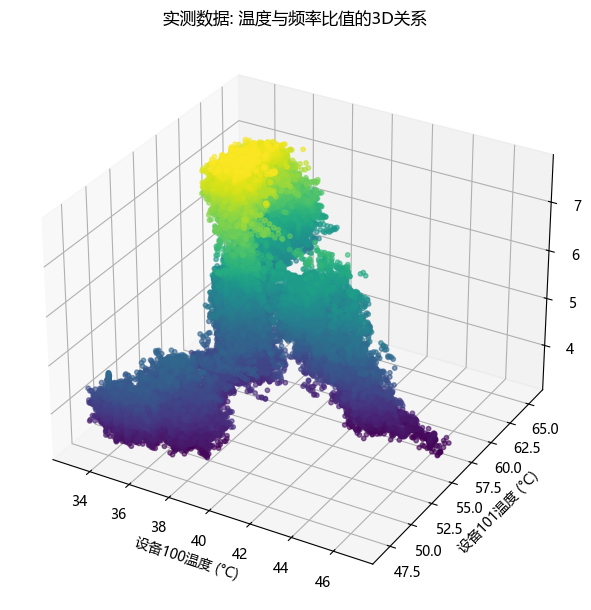

In [5]:
# 定义联合频率比模型: freq_ratio = (f1/f2) = [f01*(1-b1*(T1-T01)^2)] / [f02*(1-b2*(T2-T02)^2)]
def joint_frequency_ratio_model(temp_data, f01, b1, T01, f02, b2, T02):
    """
    联合频率比模型: freq_ratio = f1/f2 = [f01*(1-b1*(T1-T01)^2)] / [f02*(1-b2*(T2-T02)^2)]
    temp_data: [T1, T2] 两个设备的温度数组
    返回: 设备1频率/设备2频率的比值
    """
    T1, T2 = temp_data
    f1 = f01 * (1 - b1 * (T1 - T01)**2)  # 设备1的频率
    f2 = f02 * (1 - b2 * (T2 - T02)**2)  # 设备2的频率
    return f1 / f2

def fit_joint_frequency_ratio_model(temp_100, temp_101, freq_ratio):
    """拟合联合频率比模型参数"""
    from scipy.optimize import curve_fit
    
    # 初始参数估计
    f01_init = 1.0  # 设备1基准频率，归一化为1
    f02_init = 1.0  # 设备2基准频率，归一化为1
    T01_init = np.mean(temp_100)
    T02_init = np.mean(temp_101)
    b1_init = 1e-6
    b2_init = 1e-6
    
    # 准备输入数据
    temp_data = [temp_100, temp_101]
    
    try:
        popt, pcov = curve_fit(joint_frequency_ratio_model, temp_data, freq_ratio, 
                              p0=[f01_init, b1_init, T01_init, f02_init, b2_init, T02_init],
                              maxfev=10000)
        return popt, pcov
    except Exception as e:
        print(f"拟合失败: {e}")
        # 如果拟合失败，返回初始值
        return [f01_init, b1_init, T01_init, f02_init, b2_init, T02_init], None

# 拟合联合频率-温度模型
params, pcov = fit_joint_frequency_ratio_model(clean_data['temp_100'], clean_data['temp_101'], clean_data['freq_drift'])
f01, b1, T01, f02, b2, T02 = params

print(f"联合频率比模型参数:")
print(f"f₀₁ (设备100基准频率) = {f01:.6f}")
print(f"b₁ (设备100温度系数) = {b1:.2e}")
print(f"T₀₁ (设备100参考温度) = {T01:.1f}°C")
print(f"f₀₂ (设备101基准频率) = {f02:.6f}")
print(f"b₂ (设备101温度系数) = {b2:.2e}")  
print(f"T₀₂ (设备101参考温度) = {T02:.1f}°C")

# 计算预测值
y_pred = joint_frequency_ratio_model([clean_data['temp_100'], clean_data['temp_101']], 
                                    f01, b1, T01, f02, b2, T02)

# 创建可视化
fig = plt.figure(figsize=(18, 12))

# 1. 3D散点图 - 原始数据
ax1 = fig.add_subplot(231, projection='3d')
scatter = ax1.scatter(clean_data['temp_100'], 
                     clean_data['temp_101'], 
                     clean_data['freq_drift'],
                     c=clean_data['freq_drift'], 
                     cmap='viridis', 
                     alpha=0.6, s=10)
ax1.set_xlabel('设备100温度 (°C)')
ax1.set_ylabel('设备101温度 (°C)')
ax1.set_zlabel('频率比值 (f₁/f₂)')
ax1.set_title('实测数据: 温度与频率比值的3D关系')

plt.tight_layout()
plt.show()

In [10]:
# 统计分析
print("=== 联合频率比模型拟合结果 ===")
print(f"频率比模型: f₁/f₂ = [{f01:.6f} × (1 - {b1:.2e}×(T₁-{T01:.1f})²)] / [{f02:.6f} × (1 - {b2:.2e}×(T₂-{T02:.1f})²)]")
print(f"其中:")
print(f"  f₀₁ (设备100基准频率) = {f01:.6f}")
print(f"  b₁ (设备100温度系数) = {b1:.2e} /°C²")
print(f"  T₀₁ (设备100参考温度) = {T01:.1f}°C")
print(f"  f₀₂ (设备101基准频率) = {f02:.6f}")
print(f"  b₂ (设备101温度系数) = {b2:.2e} /°C²")
print(f"  T₀₂ (设备101参考温度) = {T02:.1f}°C")

# 计算拟合优度
r2_joint = stats.pearsonr(clean_data['freq_drift'], y_pred)[0]**2
print(f"\n=== 联合模型拟合优度 ===")
print(f"联合模型 R²: {r2_joint:.4f}")

# 计算均方根误差
rmse_joint = np.sqrt(np.mean((clean_data['freq_drift'] - y_pred)**2))
print(f"联合模型 RMSE: {rmse_joint:.6f}")

# 分析各设备频率的温度敏感性
f1_values = f01 * (1 - b1 * (clean_data['temp_100'] - T01)**2)
f2_values = f02 * (1 - b2 * (clean_data['temp_101'] - T02)**2)

# 计算温度变化对各设备频率的影响
temp1_deviation = clean_data['temp_100'] - T01
temp2_deviation = clean_data['temp_101'] - T02
f1_temp_effect = -b1 * temp1_deviation**2  # 设备100频率的温度效应
f2_temp_effect = -b2 * temp2_deviation**2  # 设备101频率的温度效应

print(f"\n=== 温度敏感性分析 ===")
print(f"设备100频率温度效应的平均值: {f1_temp_effect.mean():.6f}")
print(f"设备100频率温度效应的标准差: {f1_temp_effect.std():.6f}")
print(f"设备101频率温度效应的平均值: {f2_temp_effect.mean():.6f}")
print(f"设备101频率温度效应的标准差: {f2_temp_effect.std():.6f}")

# 计算相对温度敏感性 (百万分比 ppm/°C²)
ppm_per_degC2_100 = b1 * 1e6  # 设备100的ppm/°C²
ppm_per_degC2_101 = b2 * 1e6  # 设备101的ppm/°C²
print(f"\n=== 频率温度系数 (ppm/°C²) ===")
print(f"设备100: {ppm_per_degC2_100:.2f} ppm/°C²")
print(f"设备101: {ppm_per_degC2_101:.2f} ppm/°C²")

# 单独分析各设备温度与频率比值的相关性
corr_100 = stats.pearsonr(clean_data['temp_100'], clean_data['freq_drift'])[0]
corr_101 = stats.pearsonr(clean_data['temp_101'], clean_data['freq_drift'])[0]
print(f"\n=== 单变量相关性分析 ===")
print(f"设备100温度与频率比值的相关系数: {corr_100:.4f}")
print(f"设备101温度与频率比值的相关系数: {corr_101:.4f}")

# 参数不确定性分析
if pcov is not None:
    param_errors = np.sqrt(np.diag(pcov))
    param_names = ['f₀₁', 'b₁', 'T₀₁', 'f₀₂', 'b₂', 'T₀₂']
    print(f"\n=== 参数不确定性分析 ===")
    for i, (name, val, err) in enumerate(zip(param_names, params, param_errors)):
        print(f"{name}: {val:.6f} ± {err:.6f} (相对误差: {err/abs(val)*100:.2f}%)")
else:
    print(f"\n=== 参数不确定性分析 ===")
    print("无法计算参数不确定性（协方差矩阵不可用）")

# 物理意义解释
print(f"\n=== 物理意义解释 ===")
print(f"频率比值 f₁/f₂ 表示设备100相对于设备101的时钟频率比值")
print(f"当温度等于参考温度时，频率比值 = f₀₁/f₀₂ = {f01/f02:.6f}")
print(f"温度偏离参考温度越远，频率偏离基准值越大（二次关系）")
if abs(b1) > abs(b2):
    print(f"设备100的温度敏感性更高 (|b₁| > |b₂|)")
elif abs(b2) > abs(b1):
    print(f"设备101的温度敏感性更高 (|b₂| > |b₁|)")
else:
    print(f"两设备的温度敏感性相近")

print(f"\n=== 数据概览 ===")
print(f"使用的时间窗口: 1000秒")  # 使用固定值
print(f"数据点数: {len(clean_data)}")
print(f"频率比值标准差: {clean_data['freq_drift'].std():.6f}")
print(f"设备100温度范围: {clean_data['temp_100'].min():.1f}°C - {clean_data['temp_100'].max():.1f}°C")
print(f"设备101温度范围: {clean_data['temp_101'].min():.1f}°C - {clean_data['temp_101'].max():.1f}°C")

=== 联合频率比模型拟合结果 ===
频率比模型: f₁/f₂ = [3.782263 × (1 - -2.60e-08×(T₁-44.1)²)] / [3.782246 × (1 - -1.46e-08×(T₂-61.6)²)]
其中:
  f₀₁ (设备100基准频率) = 3.782263
  b₁ (设备100温度系数) = -2.60e-08 /°C²
  T₀₁ (设备100参考温度) = 44.1°C
  f₀₂ (设备101基准频率) = 3.782246
  b₂ (设备101温度系数) = -1.46e-08 /°C²
  T₀₂ (设备101参考温度) = 61.6°C

=== 联合模型拟合优度 ===
联合模型 R²: 0.6847
联合模型 RMSE: 0.000001

=== 温度敏感性分析 ===
设备100频率温度效应的平均值: 0.000001
设备100频率温度效应的标准差: 0.000001
设备101频率温度效应的平均值: 0.000001
设备101频率温度效应的标准差: 0.000001

=== 频率温度系数 (ppm/°C²) ===
设备100: -0.03 ppm/°C²
设备101: -0.01 ppm/°C²

=== 单变量相关性分析 ===
设备100温度与频率比值的相关系数: -0.3311
设备101温度与频率比值的相关系数: 0.7096

=== 参数不确定性分析 ===
f₀₁: 3.782263 ± 0.785490 (相对误差: 20.77%)
b₁: -0.000000 ± 0.000000 (相对误差: 1.58%)
T₀₁: 44.111068 ± 0.083462 (相对误差: 0.19%)
f₀₂: 3.782246 ± 0.785487 (相对误差: 20.77%)
b₂: -0.000000 ± 0.000000 (相对误差: 0.74%)
T₀₂: 61.630815 ± 0.042824 (相对误差: 0.07%)

=== 物理意义解释 ===
频率比值 f₁/f₂ 表示设备100相对于设备101的时钟频率比值
当温度等于参考温度时，频率比值 = f₀₁/f₀₂ = 1.000004
温度偏离参考温度越远，频率偏离基准值越大（二次关系）
设备100的温度敏感性更高 (

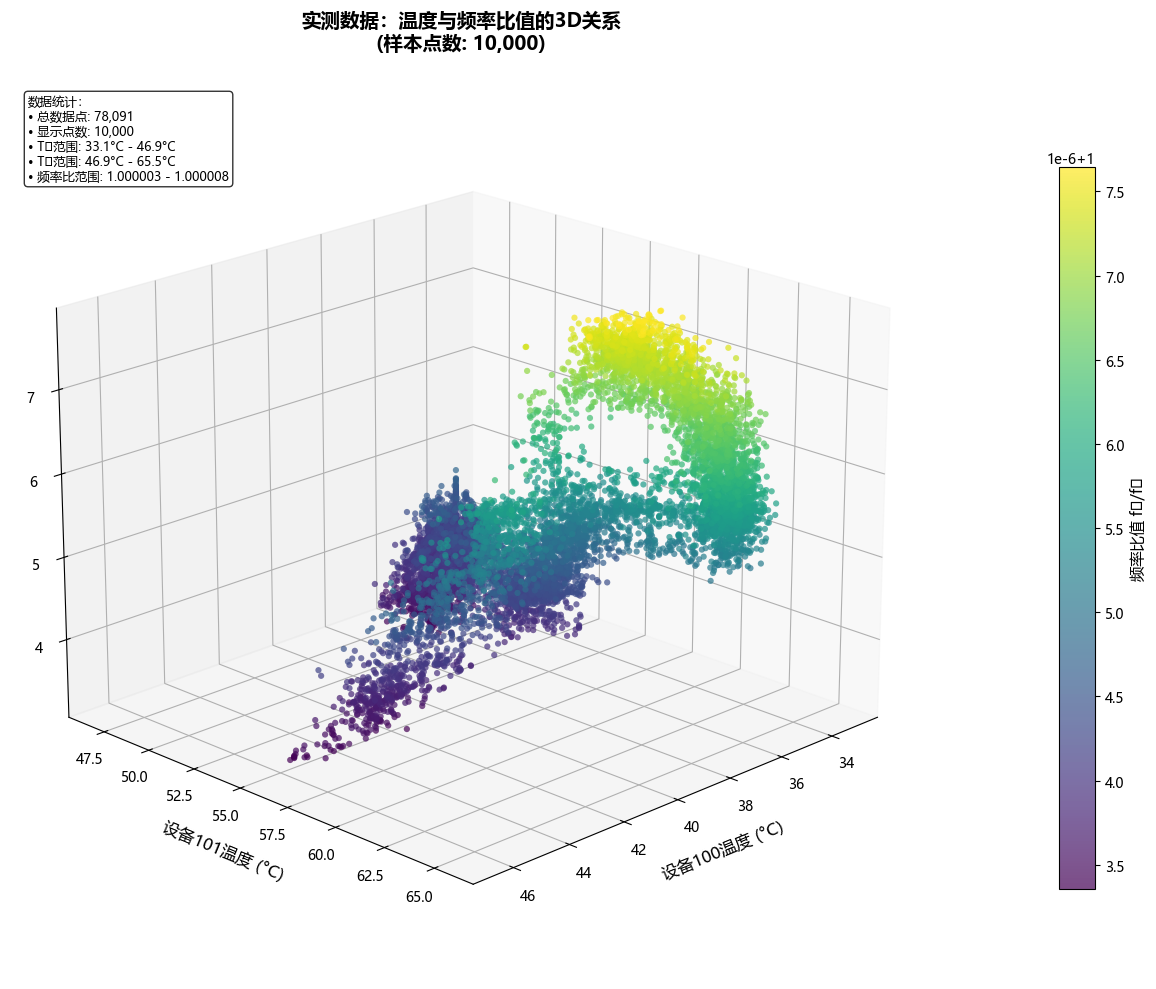


=== 3D数据可视化说明 ===
• X轴：设备100温度 (°C)
• Y轴：设备101温度 (°C)
• Z轴：频率比值 f₁/f₂
• 颜色：代表频率比值的大小（viridis配色）
• 可以看到温度变化对频率比值的复合影响
• 当前显示了 10,000 个采样点（从总共 78,091 个点中采样）


In [7]:
# 单独显示3D实测数据：温度与频率比值的关系
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# 为了更好的可视化效果，可以选择降采样数据点
n_points = min(10000, len(clean_data))  # 限制点数以提高渲染性能
indices = np.random.choice(len(clean_data), n_points, replace=False)
sample_data = clean_data.iloc[indices]

# 创建3D散点图
scatter = ax.scatter(sample_data['temp_100'], 
                     sample_data['temp_101'], 
                     sample_data['freq_drift'],
                     c=sample_data['freq_drift'], 
                     cmap='viridis', 
                     alpha=0.7, 
                     s=20,
                     edgecolors='none')

# 设置轴标签和标题
ax.set_xlabel('设备100温度 (°C)', fontsize=12, labelpad=10)
ax.set_ylabel('设备101温度 (°C)', fontsize=12, labelpad=10)
ax.set_zlabel('频率比值 f₁/f₂', fontsize=12, labelpad=10)
ax.set_title('实测数据：温度与频率比值的3D关系\n(样本点数: {:,})'.format(n_points), 
             fontsize=14, fontweight='bold', pad=20)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, aspect=20, pad=0.1)
cbar.set_label('频率比值 f₁/f₂', fontsize=11)

# 设置视角和网格
ax.view_init(elev=20, azim=45)  # 设置观察角度
ax.grid(True, alpha=0.3)

# 添加数据统计信息
stats_text = f"""数据统计：
• 总数据点: {len(clean_data):,}
• 显示点数: {n_points:,}
• T₁范围: {clean_data['temp_100'].min():.1f}°C - {clean_data['temp_100'].max():.1f}°C
• T₂范围: {clean_data['temp_101'].min():.1f}°C - {clean_data['temp_101'].max():.1f}°C
• 频率比范围: {clean_data['freq_drift'].min():.6f} - {clean_data['freq_drift'].max():.6f}"""

ax.text2D(0.02, 0.98, stats_text, transform=ax.transAxes, 
          verticalalignment='top', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n=== 3D数据可视化说明 ===")
print("• X轴：设备100温度 (°C)")
print("• Y轴：设备101温度 (°C)")
print("• Z轴：频率比值 f₁/f₂")
print("• 颜色：代表频率比值的大小（viridis配色）")
print("• 可以看到温度变化对频率比值的复合影响")
print(f"• 当前显示了 {n_points:,} 个采样点（从总共 {len(clean_data):,} 个点中采样）")

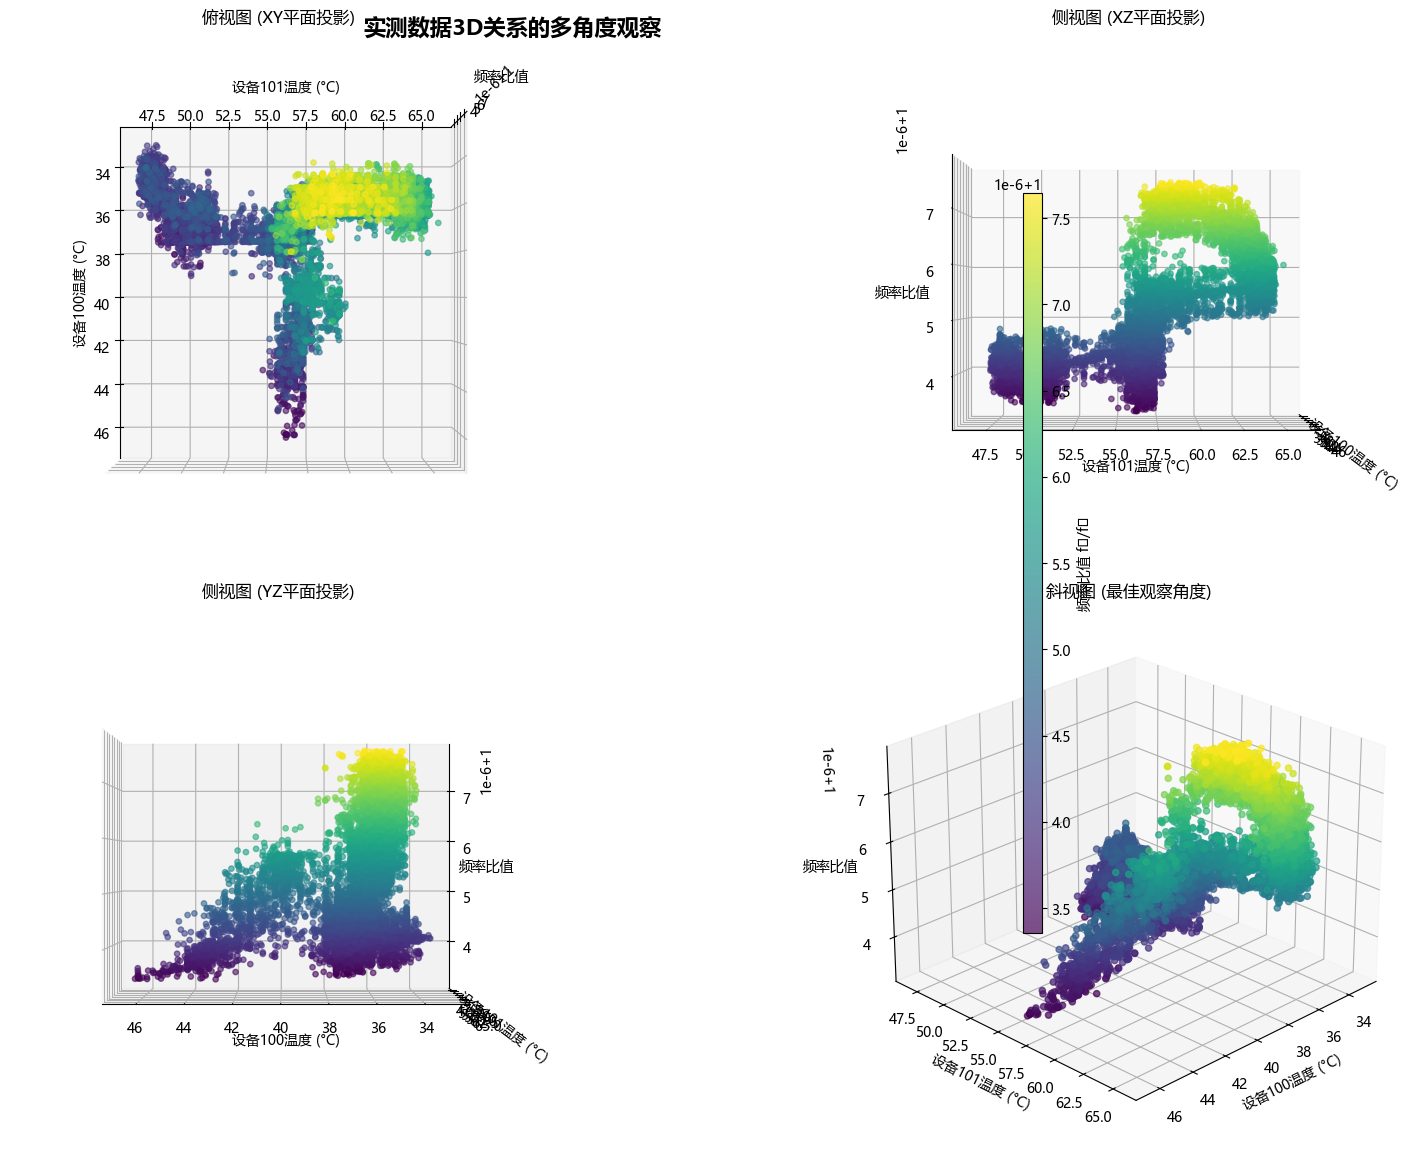


=== 多角度3D观察说明 ===
• 左上：俯视图 - 观察XY平面上的数据分布
• 右上：XZ侧视图 - 观察设备100温度与频率比值的关系
• 左下：YZ侧视图 - 观察设备101温度与频率比值的关系
• 右下：斜视图 - 最佳3D观察角度，显示完整的三维关系


In [8]:
# 创建多角度的3D投影分析
fig = plt.figure(figsize=(18, 12))

# 子图1：从上方俯视（XY平面投影）
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(sample_data['temp_100'], 
           sample_data['temp_101'], 
           sample_data['freq_drift'],
           c=sample_data['freq_drift'], 
           cmap='viridis', 
           alpha=0.6, s=15)
ax1.view_init(elev=90, azim=0)  # 从上方俯视
ax1.set_xlabel('设备100温度 (°C)')
ax1.set_ylabel('设备101温度 (°C)')
ax1.set_zlabel('频率比值')
ax1.set_title('俯视图 (XY平面投影)')

# 子图2：从侧面观察（XZ平面）
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(sample_data['temp_100'], 
           sample_data['temp_101'], 
           sample_data['freq_drift'],
           c=sample_data['freq_drift'], 
           cmap='viridis', 
           alpha=0.6, s=15)
ax2.view_init(elev=0, azim=0)  # 从侧面观察
ax2.set_xlabel('设备100温度 (°C)')
ax2.set_ylabel('设备101温度 (°C)')
ax2.set_zlabel('频率比值')
ax2.set_title('侧视图 (XZ平面投影)')

# 子图3：从另一侧面观察（YZ平面）
ax3 = fig.add_subplot(223, projection='3d')
ax3.scatter(sample_data['temp_100'], 
           sample_data['temp_101'], 
           sample_data['freq_drift'],
           c=sample_data['freq_drift'], 
           cmap='viridis', 
           alpha=0.6, s=15)
ax3.view_init(elev=0, azim=90)  # 从另一侧面观察
ax3.set_xlabel('设备100温度 (°C)')
ax3.set_ylabel('设备101温度 (°C)')
ax3.set_zlabel('频率比值')
ax3.set_title('侧视图 (YZ平面投影)')

# 子图4：斜视图（最佳观察角度）
ax4 = fig.add_subplot(224, projection='3d')
scatter = ax4.scatter(sample_data['temp_100'], 
                     sample_data['temp_101'], 
                     sample_data['freq_drift'],
                     c=sample_data['freq_drift'], 
                     cmap='viridis', 
                     alpha=0.7, s=20)
ax4.view_init(elev=25, azim=45)  # 斜视角度
ax4.set_xlabel('设备100温度 (°C)')
ax4.set_ylabel('设备101温度 (°C)')
ax4.set_zlabel('频率比值')
ax4.set_title('斜视图 (最佳观察角度)')

# 添加总体颜色条
fig.colorbar(scatter, ax=fig.get_axes(), shrink=0.8, aspect=40, pad=0.02, label='频率比值 f₁/f₂')

plt.suptitle('实测数据3D关系的多角度观察', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print("\n=== 多角度3D观察说明 ===")
print("• 左上：俯视图 - 观察XY平面上的数据分布")
print("• 右上：XZ侧视图 - 观察设备100温度与频率比值的关系")
print("• 左下：YZ侧视图 - 观察设备101温度与频率比值的关系")
print("• 右下：斜视图 - 最佳3D观察角度，显示完整的三维关系")

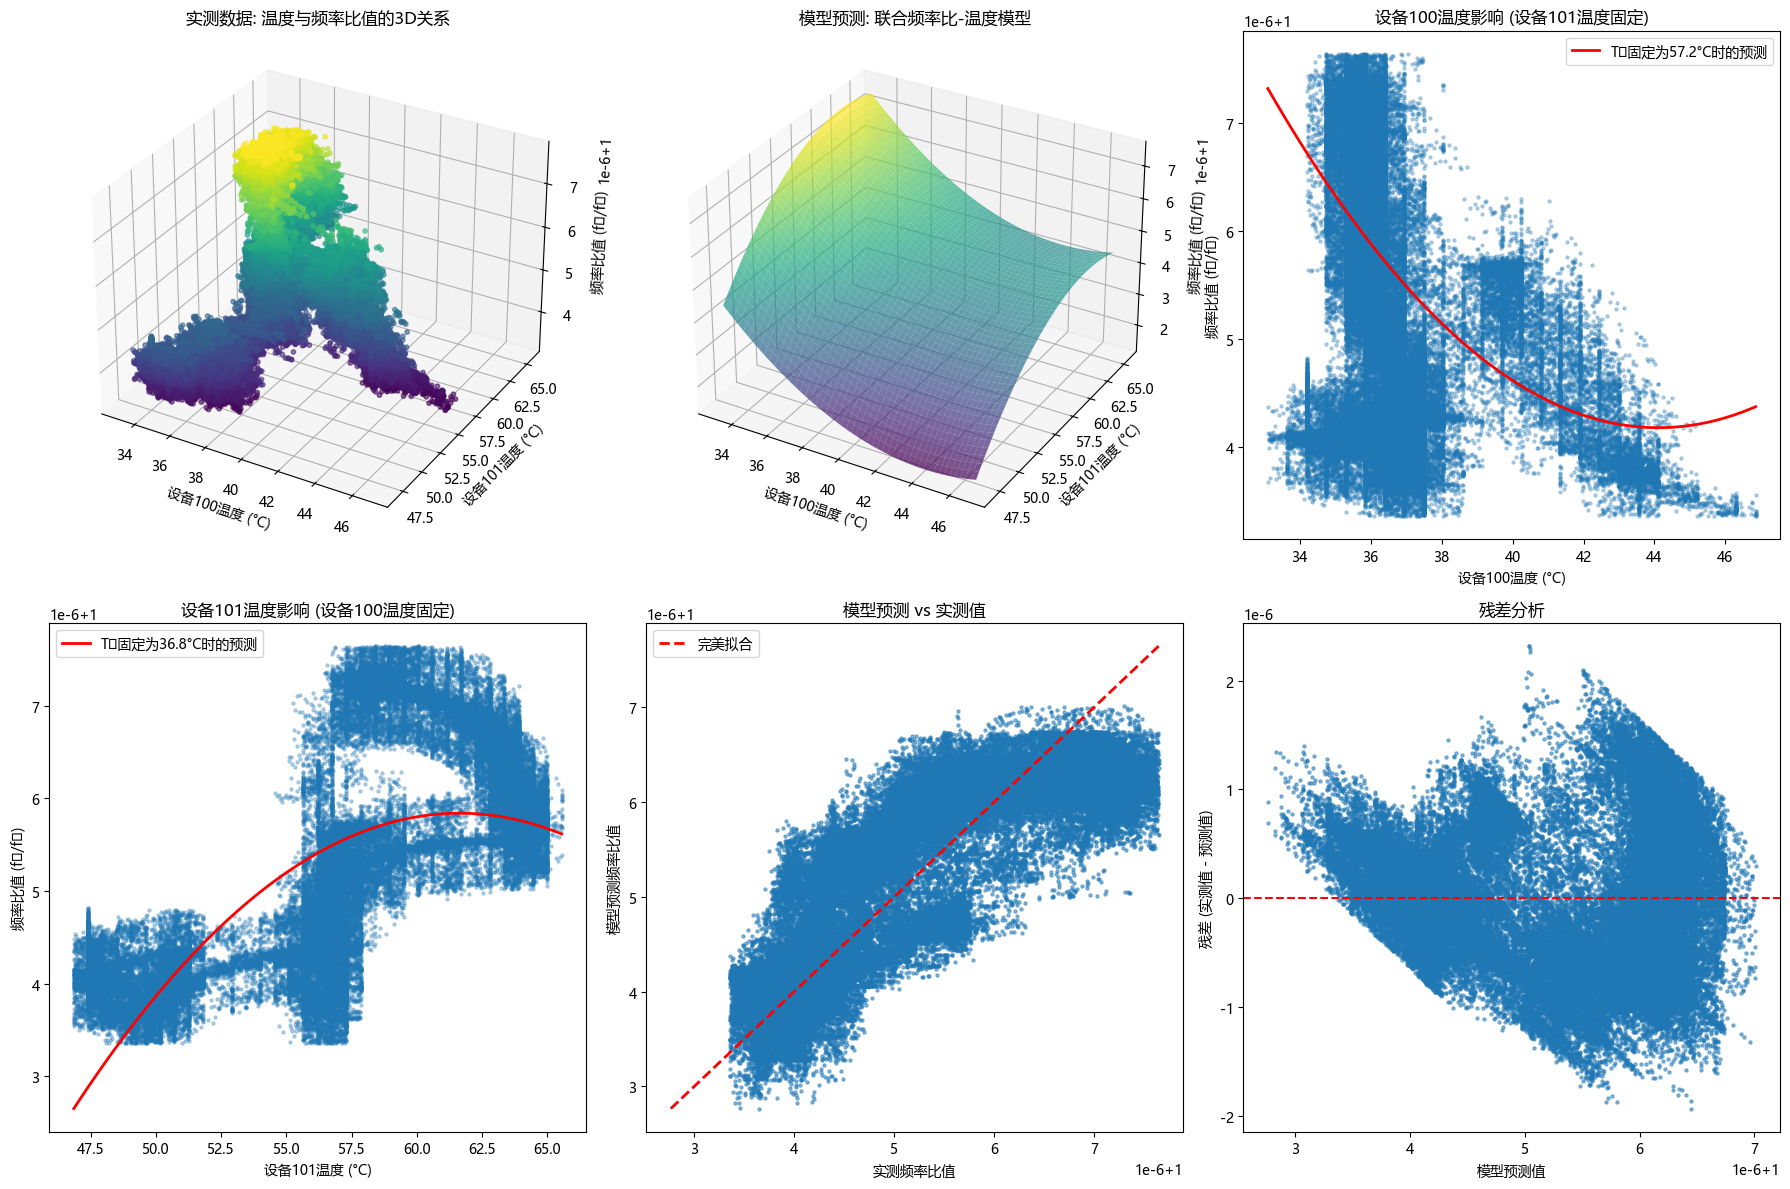

In [9]:
# 创建完整的6面板分析可视化
fig = plt.figure(figsize=(18, 12))

# 1. 3D散点图 - 原始数据
ax1 = fig.add_subplot(231, projection='3d')
scatter = ax1.scatter(clean_data['temp_100'], 
                     clean_data['temp_101'], 
                     clean_data['freq_drift'],
                     c=clean_data['freq_drift'], 
                     cmap='viridis', 
                     alpha=0.6, s=10)
ax1.set_xlabel('设备100温度 (°C)')
ax1.set_ylabel('设备101温度 (°C)')
ax1.set_zlabel('频率比值 (f₁/f₂)')
ax1.set_title('实测数据: 温度与频率比值的3D关系')

# 2. 3D曲面图 - 模型预测
ax2 = fig.add_subplot(232, projection='3d')
# 创建网格用于绘制曲面
T1_range = np.linspace(clean_data['temp_100'].min(), clean_data['temp_100'].max(), 50)
T2_range = np.linspace(clean_data['temp_101'].min(), clean_data['temp_101'].max(), 50)
T1_grid, T2_grid = np.meshgrid(T1_range, T2_range)
Z_grid = joint_frequency_ratio_model([T1_grid, T2_grid], f01, b1, T01, f02, b2, T02)

surf = ax2.plot_surface(T1_grid, T2_grid, Z_grid, cmap='viridis', alpha=0.7)
ax2.set_xlabel('设备100温度 (°C)')
ax2.set_ylabel('设备101温度 (°C)')
ax2.set_zlabel('频率比值 (f₁/f₂)')
ax2.set_title('模型预测: 联合频率比-温度模型')

# 3. 设备100温度 vs 频率比值（固定设备101温度为平均值）
ax3 = fig.add_subplot(233)
ax3.scatter(clean_data['temp_100'], clean_data['freq_drift'], alpha=0.3, s=5)
# 在设备101温度固定为平均值时的预测曲线
T1_fit = np.linspace(clean_data['temp_100'].min(), clean_data['temp_100'].max(), 100)
T2_fixed = np.full_like(T1_fit, clean_data['temp_101'].mean())
y_fit_T1 = joint_frequency_ratio_model([T1_fit, T2_fixed], f01, b1, T01, f02, b2, T02)
ax3.plot(T1_fit, y_fit_T1, 'r-', linewidth=2, 
         label=f'T₂固定为{clean_data["temp_101"].mean():.1f}°C时的预测')
ax3.set_xlabel('设备100温度 (°C)')
ax3.set_ylabel('频率比值 (f₁/f₂)')
ax3.set_title('设备100温度影响 (设备101温度固定)')
ax3.legend()

# 4. 设备101温度 vs 频率比值（固定设备100温度为平均值）
ax4 = fig.add_subplot(234)
ax4.scatter(clean_data['temp_101'], clean_data['freq_drift'], alpha=0.3, s=5)
# 在设备100温度固定为平均值时的预测曲线
T2_fit = np.linspace(clean_data['temp_101'].min(), clean_data['temp_101'].max(), 100)
T1_fixed = np.full_like(T2_fit, clean_data['temp_100'].mean())
y_fit_T2 = joint_frequency_ratio_model([T1_fixed, T2_fit], f01, b1, T01, f02, b2, T02)
ax4.plot(T2_fit, y_fit_T2, 'r-', linewidth=2,
         label=f'T₁固定为{clean_data["temp_100"].mean():.1f}°C时的预测')
ax4.set_xlabel('设备101温度 (°C)')
ax4.set_ylabel('频率比值 (f₁/f₂)')
ax4.set_title('设备101温度影响 (设备100温度固定)')
ax4.legend()

# 5. 预测值 vs 实测值
ax5 = fig.add_subplot(235)
ax5.scatter(clean_data['freq_drift'], y_pred, alpha=0.5, s=5)
# 添加完美拟合线
min_val = min(clean_data['freq_drift'].min(), y_pred.min())
max_val = max(clean_data['freq_drift'].max(), y_pred.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美拟合')
ax5.set_xlabel('实测频率比值')
ax5.set_ylabel('模型预测频率比值')
ax5.set_title('模型预测 vs 实测值')
ax5.legend()

# 6. 残差分析
ax6 = fig.add_subplot(236)
residuals = clean_data['freq_drift'] - y_pred
ax6.scatter(y_pred, residuals, alpha=0.5, s=5)
ax6.axhline(y=0, color='r', linestyle='--')
ax6.set_xlabel('模型预测值')
ax6.set_ylabel('残差 (实测值 - 预测值)')
ax6.set_title('残差分析')

plt.tight_layout()
plt.show()